In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC

iris = sns.load_dataset("iris") 
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [29]:
data = iris[['sepal_length', 'petal_length', 'species']]
data_df = data[(data["species"] =="setosa") & (data['petal_length'] > 1.5) | (data["species"] == "versicolor") & (data['petal_length'] < 4)]

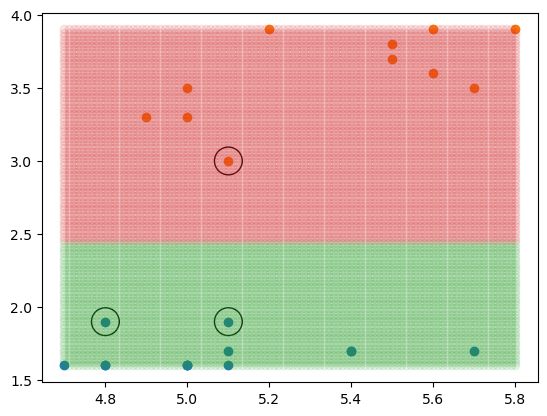

In [31]:
X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

data_df_seposa = data_df[data_df["species"] == "setosa"] 
data_df_versicolor = data_df[data_df["species"] == "versicolor"]

plt.scatter(data_df_seposa["sepal_length"], data_df_seposa["petal_length"]) 
plt.scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])

model = SVC(kernel='linear', C=10000)
model.fit(X, y)

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=400, facecolor='none', edgecolors='black')

x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)

X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

y_p = model.predict(X_p)

X_p["species"] = y_p

X_p_setosa = X_p[X_p["species"] == "setosa"]
X_p_versicolor = X_p[X_p["species"] == "versicolor"]

plt.scatter(X_p_setosa["sepal_length"], X_p_setosa["petal_length"], alpha=0.1)
plt.scatter(X_p_versicolor["sepal_length"], X_p_versicolor["petal_length"], alpha=0.1)

plt.show()